In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from matplotlib.ticker import FormatStrFormatter

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../../03-stratified_RankSumTest_1vsOthers/01_subclasses_in_neuron_1vsOthers'
outdir = './'

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties

path = "/arial/arial.ttf"
fontManager.addfont(path)
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 5

prop = FontProperties(fname=path)
sns.reset_defaults()
sns.set(context=None,
    style=None,
    palette=None,
    font=prop.get_name(),
    font_scale=None,
    color_codes=None,
    rc=None,)

the_padding=0.6
red_alpha=0.7
hist_width=44
the_upper_ylim=1.075
bar_width=0.55
errorbar_setting={"ecolor":"black","elinewidth":0.6,"capsize":2.5,"capthick":0.6,"fmt":"none"}

In [ ]:
subclass_list=pd.read_csv('../../../../03.data/04.config_files/subclass_order.csv', header=None).loc[:, 0].to_list()
subclass_list=[i for i in subclass_list if "NN" not in i]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

5mC	hyper	11635 DMRs
5mC	hypo	121154 DMRs


  0%|          | 0/2 [00:00<?, ?it/s]

5hmC	hyper	152517 DMRs
5hmC	hypo	70317 DMRs


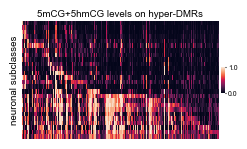

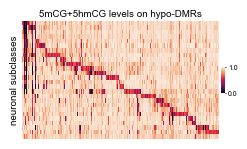

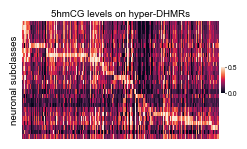

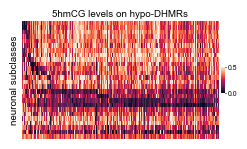

In [ ]:
for modification in tqdm(["5mC", "5hmC"]):
    for state in tqdm(["hyper", "hypo"]):
        DMR_states_df=ad.read_h5ad(f"{indir}/{modification}G_DMR_states_neuron_1vsOthers.h5ad").to_df()
        if state == "hyper":
            flag=1
        elif state == "hypo":
            flag=-1
            
        temp_list=[]
        for region_ in DMR_states_df.columns:
            diff_subclass = DMR_states_df.index[DMR_states_df[region_]==flag]
            if diff_subclass.any():
                temp_list.append([region_,diff_subclass])
        df_DMR_geneid_diff=pd.DataFrame(
            sorted(
                temp_list,
                key=lambda x : sorted([subclass_list.index(i) for i in x[1]])
            ),
            columns=["segment", "diff_subclass"]
            )

        df_frac_segment_subclass = ad.read_h5ad(f'{modification}_merged_allc_with_{modification}_segment.h5ad').to_df()
        df_frac_segment_subclass = df_frac_segment_subclass.iloc[:len(subclass_list),:]
        df_frac_segment_subclass.index = subclass_list
        
        df_frac_selected = df_frac_segment_subclass.loc[:,df_DMR_geneid_diff['segment']]
        
        # remove rows containing NAs
        df_frac_selected = df_frac_selected.loc[:, df_frac_selected.count(axis=0)==df_frac_selected.shape[0]]

        print(modification, state, f'{df_frac_selected.shape[1]} DMRs', sep="\t")
        
        figure_size_setting=(60/25.4, 35/25.4)

        plt.rcParams['figure.constrained_layout.use'] = True
        plt.figure(figsize=figure_size_setting)
        ax=sns.heatmap(df_frac_selected,vmin=0,vmax=(0.5 if modification == "5hmC" else 1), cmap="rocket", yticklabels=False,xticklabels=False,
                      cbar_kws={"drawedges": False, "pad":0.01, 'shrink': 0.22, "aspect": 6})
        ax.tick_params(labelsize=5,pad=1,length=0)
        cbar=ax.collections[0].colorbar
        cbar.ax.set_yticks([0,(0.5 if modification == "5hmC" else 1)])
        cbar.ax.set_xticks([])
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        cbar.ax.tick_params(labelsize=5,labelcolor="black",length=1,pad=1)
        plt.xlabel("",fontdict={"size":7}, labelpad=2)
        plt.title(f"{'5hmCG' if modification=='5hmC' else '5mCG+5hmCG'} levels on {state}-{'DHMR' if modification=='5hmC' else 'DMR'}s",fontdict={"size":7},pad=3)
        plt.ylabel(f"neuronal subclasses",fontdict={"size":7}, labelpad=2)
        #plt.show()
        plt.savefig(f'{outdir}/DMR_plot_{'_'.join([modification+'G', state])}.pdf')
        plt.savefig(f'{outdir}/DMR_plot_{'_'.join([modification+'G', state])}.png', dpi=600)